# NYC Hourly Taxi Demand — EDA

Exploratory analysis of `fct_hourly_demand`, the dbt mart that feeds the demand-prediction model.

**Grain:** one row per `(pickup_location_id, pickup_hour_ts)`. Two years of data (2024–2025), ~265 zones, joined with daily NOAA weather and the `dim_date` calendar.

**What this notebook covers:**
1. Dataset shape and basic statistics
2. The hourly demand cycle (24-hour pattern)
3. Day-of-week pattern
4. Borough distribution and zone concentration
5. Weather correlation
6. Sparsity and what makes this a hard forecasting problem

**What this notebook *isn't*:** a model write-up. See `03_model_results.ipynb` for the modeling story.

## Setup

Import the project's chart helpers (`../../notebooks/eda_helpers.py`) plus `config.py` for the Snowflake connection. The `sql()` helper below mirrors what's used elsewhere in the project — `fetch_pandas_all()` so NUMBER columns come back as float64, fallback to `fetchall()` for SHOW/DESCRIBE queries.

In [6]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import snowflake.connector

# Resolve project paths from this notebook's location
ML_ROOT   = Path.cwd().resolve().parent          # ml/demand_prediction/
REPO_ROOT = ML_ROOT.parent.parent                # portfolio_nyc_tlc/

sys.path.insert(0, str(REPO_ROOT / 'notebooks'))   # eda_helpers.py
sys.path.insert(0, str(ML_ROOT))                   # config.py

%load_ext autoreload
%autoreload 2

from eda_helpers import *
import config

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 100})

conn = config.get_snowflake_connection()

def sql(query: str) -> pd.DataFrame:
    """Execute SQL and return a DataFrame with native pandas dtypes."""
    cur = conn.cursor()
    cur.execute(query)
    try:
        df = cur.fetch_pandas_all()
    except snowflake.connector.errors.NotSupportedError:
        rows = cur.fetchall()
        cols = [d[0] for d in cur.description] if cur.description else []
        df = pd.DataFrame(rows, columns=cols)
    df.columns = [c.lower() for c in df.columns]
    return df

print('Connected — querying fct_hourly_demand')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Connected — querying fct_hourly_demand


## 1. Dataset overview

How big is the table, what date range does it span, and how many distinct zones contribute trips?

In [7]:
stats = sql("""
    SELECT
        COUNT(*)                            AS row_count,
        COUNT(DISTINCT pickup_location_id)  AS distinct_zones,
        MIN(pickup_hour_ts)                 AS first_hour,
        MAX(pickup_hour_ts)                 AS last_hour,
        SUM(trip_count)                     AS total_trips,
        AVG(trip_count)                     AS avg_trips_per_zone_hour
    FROM fct_hourly_demand
""")
stats.T

,0
row_count,2492288
distinct_zones,263
first_hour,2024-01-01 00:00:00
last_hour,2025-12-31 23:00:00
total_trips,89891490
avg_trips_per_zone_hour,36.067858


## 2. Hourly demand cycle

What does an average day look like? Aggregating across the entire dataset, the citywide demand pattern by hour-of-day shows the rhythm of NYC's taxi usage.

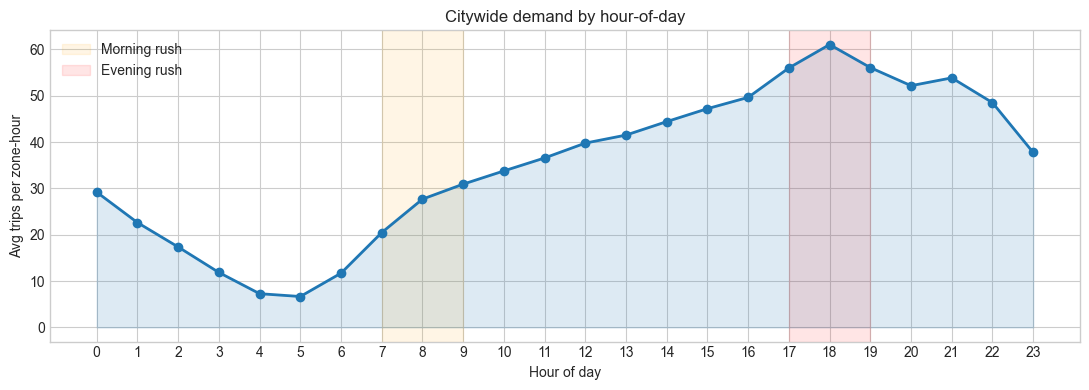

In [8]:
hourly = sql("""
    SELECT pickup_hour, AVG(trip_count) AS avg_trips_per_zone
    FROM fct_hourly_demand
    GROUP BY 1
    ORDER BY 1
""")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(hourly['pickup_hour'], hourly['avg_trips_per_zone'],
        marker='o', color='#1f77b4', linewidth=2)
ax.fill_between(hourly['pickup_hour'], hourly['avg_trips_per_zone'],
                alpha=0.15, color='#1f77b4')
ax.axvspan(7, 9, alpha=0.10, color='orange', label='Morning rush')
ax.axvspan(17, 19, alpha=0.10, color='red',    label='Evening rush')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Avg trips per zone-hour')
ax.set_title('Citywide demand by hour-of-day')
ax.set_xticks(range(0, 24))
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

**Reading:** Demand bottoms out in the small hours (3–5am), ramps quickly into the morning commute, plateaus through midday, and peaks during the evening rush (5–7pm). The model needs to capture this 24-hour cycle — which is exactly what the cyclical encoding (`hour_sin`/`hour_cos`) and the same-hour-DoW lag features are designed to do.

Note the long tail into late night: NYC taxi demand stays meaningfully non-zero past midnight, unlike most cities.

## 3. Day-of-week pattern

Demand also varies by day of the week. Friday and Saturday nights tell a different story from Tuesday mornings.

,day_of_week,day_name,avg_trips_per_zone_hour
0,0,Sun,31.709263
1,1,Mon,31.398728
2,2,Tue,36.609205
3,3,Wed,38.436904
4,4,Thu,39.667789
5,5,Fri,36.925990
6,6,Sat,38.053954


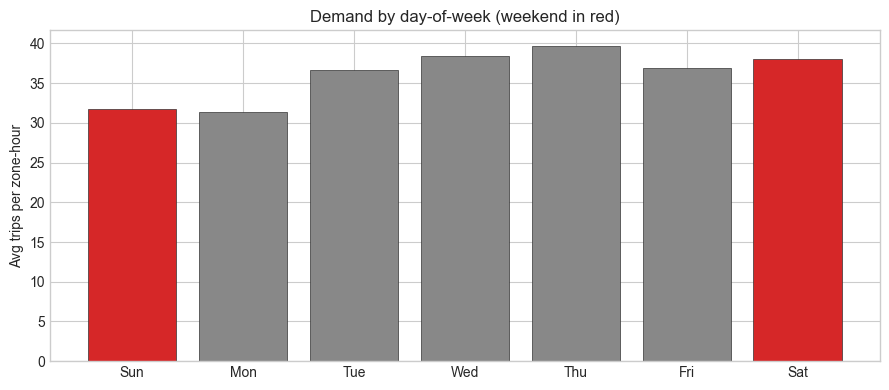

In [10]:
dow = sql("""
    SELECT
        day_of_week,
        MIN(DAYNAME(pickup_date))      AS day_name,
        AVG(trip_count)                AS avg_trips_per_zone_hour
    FROM fct_hourly_demand
    WHERE day_of_week IS NOT NULL
    GROUP BY day_of_week
    ORDER BY day_of_week
""")

# Show what we actually got back so the chart is self-explaining if the
# day_of_week numbering ever surprises us (Snowflake's DAYOFWEEK default
# is 0=Sun..6=Sat, but with WEEK_START set it can be 1=Sun..7=Sat or
# 1=Mon..7=Sun — pulling DAYNAME directly avoids guessing).
display(dow)

# Use the day_name column for x-axis labels — already strings, no map needed
weekend_set = {'Sat', 'Sun'}
colors = ['#d62728' if d in weekend_set else '#888' for d in dow['day_name']]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(dow['day_name'], dow['avg_trips_per_zone_hour'],
       color=colors, edgecolor='#333', linewidth=0.5)
ax.set_ylabel('Avg trips per zone-hour')
ax.set_title('Demand by day-of-week (weekend in red)')
plt.tight_layout()
plt.show()

**Reading:** Weekday demand is roughly flat Tuesday–Thursday. Friday peaks (mix of commuters + early weekend nightlife). Saturday and Sunday dip slightly — fewer commuters but airport and tourism trips persist.

The narrow weekday-to-weekend range (~10%) is a tell that hour-of-day dominates day-of-week as a predictor — which the SHAP analysis later confirms (`hour_sin` doesn't even crack the top 15 features, while same-hour-DoW lags do).

## 4. Borough distribution

Where is the demand? NYC taxi ridership is famously Manhattan-heavy.

In [11]:
borough = sql("""
    SELECT pickup_borough, SUM(trip_count) AS total_trips
    FROM fct_hourly_demand
    GROUP BY 1
    ORDER BY 2 DESC
""")
borough['pct'] = borough['total_trips'] / borough['total_trips'].sum() * 100
borough.style.format({'total_trips': '{:,.0f}', 'pct': '{:.1f}%'})

,pickup_borough,total_trips,pct
0,manhattan,"78,221,733",87.0%
1,queens,"8,530,256",9.5%
2,brooklyn,"2,367,254",2.6%
3,bronx,"504,449",0.6%
4,unknown,"203,069",0.2%
5,n/a,"46,171",0.1%
6,ewr,"11,996",0.0%
7,staten island,"6,562",0.0%


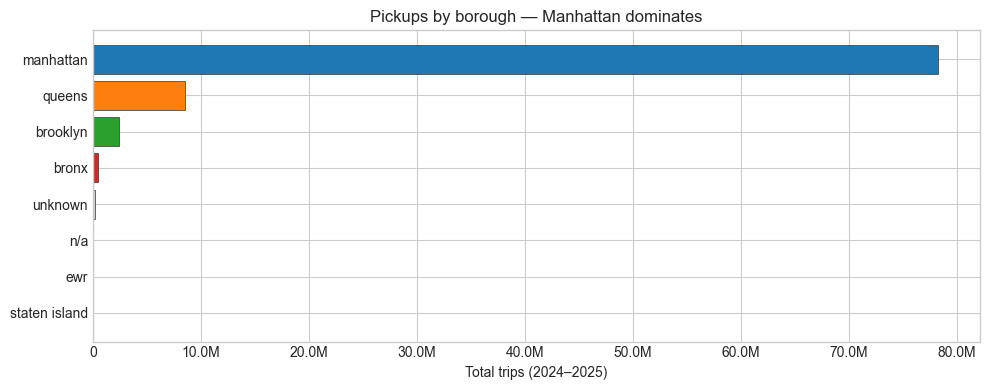

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
colors = [BOROUGH_COLORS.get(b, '#888888') for b in borough['pickup_borough']]
ax.barh(borough['pickup_borough'][::-1], borough['total_trips'][::-1],
        color=colors[::-1], edgecolor='#333', linewidth=0.5)
ax.set_xlabel('Total trips (2024–2025)')
ax.set_title('Pickups by borough — Manhattan dominates')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: fmt_num(x)))
plt.tight_layout()
plt.show()

**Reading:** Manhattan accounts for the vast majority of pickups — typical for NYC TLC data, and consistent with the model's per-borough MAE breakdown showing Manhattan zones produce both the highest absolute volumes and the highest absolute prediction errors. Most of the modeling "work" lives in Manhattan.

## 5. Weather correlation

Does it really rain on demand? Aggregating each day's total trips against the day's average temperature.

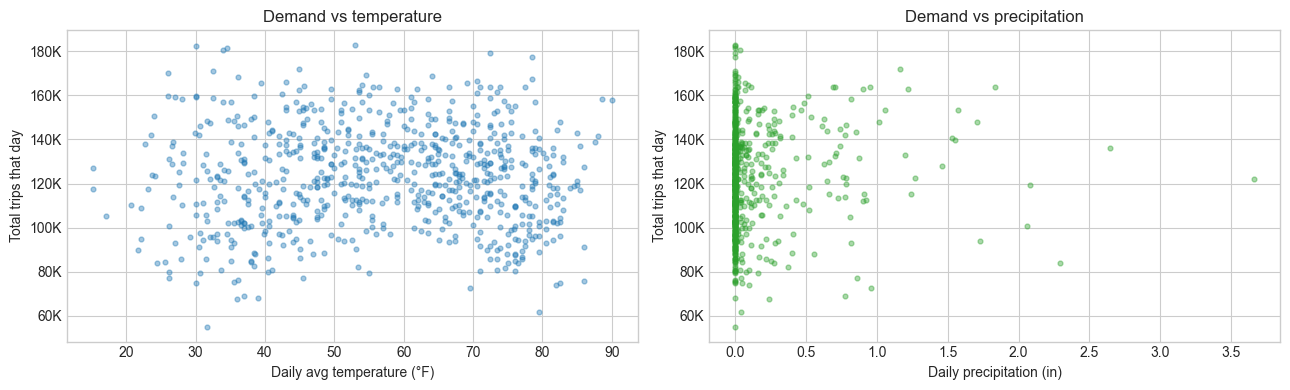

Pearson r (temp vs trips):    0.008
Pearson r (precip vs trips):  0.067


In [14]:
daily = sql("""
    SELECT
        pickup_date,
        AVG(temp_avg_f)        AS temp_avg_f,
        AVG(precipitation_in)  AS precipitation_in,
        SUM(trip_count)        AS total_trips
    FROM fct_hourly_demand
    WHERE temp_avg_f IS NOT NULL
    GROUP BY 1
    ORDER BY 1
""")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(daily['temp_avg_f'], daily['total_trips'],
                alpha=0.4, s=12, color='#1f77b4')
axes[0].set_xlabel('Daily avg temperature (°F)')
axes[0].set_ylabel('Total trips that day')
axes[0].set_title('Demand vs temperature')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: fmt_num(x)))

axes[1].scatter(daily['precipitation_in'], daily['total_trips'],
                alpha=0.4, s=12, color='#2ca02c')
axes[1].set_xlabel('Daily precipitation (in)')
axes[1].set_ylabel('Total trips that day')
axes[1].set_title('Demand vs precipitation')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: fmt_num(x)))

plt.tight_layout()
plt.show()

print(f'Pearson r (temp vs trips):    {daily[["temp_avg_f",       "total_trips"]].corr().iloc[0, 1]:.3f}')
print(f'Pearson r (precip vs trips):  {daily[["precipitation_in", "total_trips"]].corr().iloc[0, 1]:.3f}')

**Reading:** Both correlations are weak — temperature has a small positive effect (warmer days → slightly more trips), and precipitation is essentially flat. This matches the SHAP analysis where weather features rank 10–15 in importance, well below lag features.

Two caveats worth noting:
1. **Daily-grain weather** repeated across all 24 hours of the day washes out hourly weather effects (a thunderstorm at 4pm reads as drizzle when averaged over a clear morning).
2. **Calendar correlates with weather** — cold months are also holiday-heavy. Some weather signal gets absorbed into holiday/calendar features and the lags.

## 6. Sparsity and the forecasting challenge

Why is hourly demand prediction at zone grain hard? Two structural reasons: most zone-hours have very few trips, and the distribution is severely skewed.

In [15]:
buckets = sql("""
    SELECT
        CASE
            WHEN trip_count = 0          THEN '0 (zero hour)'
            WHEN trip_count BETWEEN 1 AND 5    THEN '1-5'
            WHEN trip_count BETWEEN 6 AND 25   THEN '6-25'
            WHEN trip_count BETWEEN 26 AND 100 THEN '26-100'
            ELSE '100+'
        END                  AS bucket,
        COUNT(*)             AS n_zone_hours,
        SUM(trip_count)      AS total_trips
    FROM fct_hourly_demand
    GROUP BY 1
    ORDER BY MIN(trip_count)
""")
buckets['pct_rows'] = buckets['n_zone_hours'] / buckets['n_zone_hours'].sum() * 100
buckets['pct_trips'] = buckets['total_trips'] / buckets['total_trips'].sum() * 100
buckets.style.format({
    'n_zone_hours': '{:,.0f}',
    'total_trips':  '{:,.0f}',
    'pct_rows':     '{:.1f}%',
    'pct_trips':    '{:.1f}%',
})

,bucket,n_zone_hours,total_trips,pct_rows,pct_trips
0,1-5,"1,357,953","2,806,690",54.5%,3.1%
1,6-25,"488,924","5,937,299",19.6%,6.6%
2,26-100,"339,346","19,082,660",13.6%,21.2%
3,100+,"306,065","62,064,841",12.3%,69.0%


## Takeaways for the model

1. **Hour-of-day dominates the signal.** Demand has a strong, predictable 24-hour cycle. Lag features at 24h and 168h (= same hour, same day-of-week) are essentially designed to capture this.
2. **Weekly seasonality is the second-most important pattern.** This is why the same-hour-DoW lag (`lag_t24_1w`) is the model's #1 feature in SHAP analysis.
3. **Manhattan dominates volume.** Most absolute prediction error lives there — it's both the busiest and the highest-variance borough.
4. **Weather is a weak predictor at this grain.** Daily-grain weather repeated across hourly slices loses signal. If we ever upgrade to hourly weather, the weather features could matter more.
5. **The data is heavy-tailed.** A small fraction of zone-hours produce most of the trips. A model that predicts well in the long tail (low-volume zones, late-night hours) needs different signals than one that predicts well in the busy core.

These observations directly inform the modeling choices in `03_model_results.ipynb`:
- A 4-week DoW-average baseline (captures the dominant signal)
- Lag features at 1h, 2h, 24h, 48h, 168h **plus target-aligned weekly lags** at 144/312/480/648h
- Cyclical encodings for hour, day-of-week, month
- LightGBM with Optuna tuning
- SHAP for interpretability